### XGBoostRegressor Model Training

In [1]:
## 1. Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

In [2]:
## 2. Function for loading the Dataset
def load_and_prepare_data(csv_path: str = '../../../data/earthquakes_data_preprocessed.csv'):
    """Load dataset and prepare features/target (NO Latitude/Longitude)."""
    print("Loading earthquake data...")
    df = pd.read_csv(csv_path)
    print(f"Dataset shape: {df.shape}")
    
    print("\nTarget variable (risk_score) statistics:")
    print(df['risk_score'].describe())
    
    # Remove target and spatial features
    exclude_cols = ['risk_score', 'Latitude', 'Longitude']
    X = df.drop(columns=[col for col in exclude_cols if col in df.columns])
    y = df['risk_score']
    
    print(f"\nFeatures shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    print("\nFeature columns:")
    print(X.columns.tolist())
    
    return X, y

# Test the function
X, y = load_and_prepare_data()


Loading earthquake data...
Dataset shape: (109715, 7)

Target variable (risk_score) statistics:
count    109715.000000
mean          1.090893
std           4.596779
min           0.007580
25%           0.154545
50%           0.297691
75%           0.655000
max          85.617038
Name: risk_score, dtype: float64

Features shape: (109715, 6)
Target shape: (109715,)

Feature columns:
['depth', 'rms', 'Mw', 'damage_potential', 'urbanity_indicator', 'decade']


In [3]:
## 3. XGBoost Regressor Model Training
def train_xgboost_model(X_train, y_train):
    """Train XGBoost regressor with optimized hyperparameters."""
    model = XGBRegressor(
        n_estimators=1000,      # 1000 trees
        max_depth=6,           # Tree depth
        learning_rate=0.1,     # Step size
        subsample=0.8,         # Row sampling
        colsample_bytree=0.8,  # Column sampling
        reg_alpha=0.1,         # L1 regularization
        reg_lambda=1.0,        # L2 regularization
        random_state=42,       # Reproducibility
        n_jobs=-1,             # All CPU cores
        eval_metric='rmse'     # Evaluation metric
    )
    
    print("Fitting model (full 1000 estimators)...")
    model.fit(X_train, y_train)
    
    print("✓ Model training completed!")
    return model


In [4]:
## 4. Model Evaluation
def evaluate_model(model, X_val, y_val):
    """Evaluate model performance and return metrics."""
    print("\n" + "="*60)
    print("MODEL EVALUATION RESULTS")
    print("="*60)
    
    # Predictions
    y_pred = model.predict(X_val)
    
    # Calculate metrics
    mae = mean_absolute_error(y_val, y_pred)
    mse = mean_squared_error(y_val, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_val, y_pred)
    
    # Print metrics
    print(f"Mean Absolute Error (MAE):  {mae:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Squared Error (MSE):   {mse:.4f}")
    print(f"R² Score:                    {r2:.4f}")
    
    return {
        'mae': mae,
        'rmse': rmse,
        'mse': mse,
        'r2': r2,
        'y_true': y_val,
        'y_pred': y_pred
    }


In [5]:
## 5. Performance Visualization
def plot_model_performance(metrics_dict):
    """Create comprehensive model performance visualizations."""
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('XGBoost Model Performance', 
                 fontsize=16, fontweight='bold')
    
    # 1. Actual vs Predicted
    axes[0, 0].scatter(metrics_dict['y_true'], metrics_dict['y_pred'], alpha=0.6, s=1)
    axes[0, 0].plot([metrics_dict['y_true'].min(), metrics_dict['y_true'].max()],
                    [metrics_dict['y_true'].min(), metrics_dict['y_true'].max()], 'r--', lw=2)
    axes[0, 0].set_xlabel('Actual Risk Score')
    axes[0, 0].set_ylabel('Predicted Risk Score')
    axes[0, 0].set_title('Actual vs Predicted')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Residuals plot
    residuals = metrics_dict['y_true'] - metrics_dict['y_pred']
    axes[0, 1].scatter(metrics_dict['y_pred'], residuals, alpha=0.6, s=1)
    axes[0, 1].axhline(y=0, color='r', linestyle='--')
    axes[0, 1].set_xlabel('Predicted Risk Score')
    axes[0, 1].set_ylabel('Residuals')
    axes[0, 1].set_title('Residuals Plot')
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Prediction error distribution
    axes[1, 0].hist(residuals, bins=50, alpha=0.7, edgecolor='black')
    axes[1, 0].axvline(residuals.mean(), color='r', linestyle='--', 
                       label=f'Mean: {residuals.mean():.3f}')
    axes[1, 0].set_xlabel('Residuals')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Residuals Distribution')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # 4. Metrics summary
    metrics = ['mae', 'rmse', 'r2']
    values = [metrics_dict[m] for m in metrics]
    axes[1, 1].bar(metrics, values, color=['skyblue', 'lightcoral', 'lightgreen'], alpha=0.8)
    axes[1, 1].set_title('Key Metrics')
    axes[1, 1].set_ylabel('Score')
    for i, v in enumerate(values):
        axes[1, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('xgboost_performance.png', dpi=300, bbox_inches='tight')
    plt.show()
    


In [6]:
## 6. Feature Importance Visualization
def plot_feature_importance(model, X_train):
    """Plot top 20 feature importances from the trained model."""    
    # Get feature names
    feature_names = X_train.columns.tolist()
    
    # Get importance from XGBoost
    importance = model.feature_importances_
    
    # Create importance DataFrame
    importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values('importance', ascending=True).tail(20)
    
    # Plot
    plt.figure(figsize=(12, 8))
    plt.barh(importance_df['feature'], importance_df['importance'])
    plt.xlabel('Importance Score')
    plt.title('Top 20 Feature Importance - XGBoost')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('xgboost_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Feature importance plot saved as 'xgboost_importance.png'")
    print("\nTop 20 Most Important Features:")
    print(importance_df.tail(20)[['feature', 'importance']].round(4))


In [7]:
## 7. Model Saving Function
def save_model_and_metrics(model, metrics_dict, X_train, filepath: str = 'models/xgboost.pkl'):
    """Save trained model and metrics."""
    print(f"\nSaving model to {filepath}...")
    
    # Save model
    joblib.dump(model, filepath)
    
    # Save metrics
    metrics_df = pd.DataFrame([metrics_dict]).round(4)
    metrics_df.to_csv('models/xgboost_metrics.csv', index=False)
    
    print("✓ Model and metrics saved successfully!")
    print("\nModel artifacts:")
    print(f"  - Model: {filepath}")
    print(f"  - Metrics: models/xgboost_metrics.csv")
    print(f"  - Plots: xgboost_performance.png")
    print(f"  - Plots: xgboost_importance.png")


🚀 Starting XGBoost Earthquake Risk Prediction Pipeline
Loading earthquake data...
Dataset shape: (109715, 7)

Target variable (risk_score) statistics:
count    109715.000000
mean          1.090893
std           4.596779
min           0.007580
25%           0.154545
50%           0.297691
75%           0.655000
max          85.617038
Name: risk_score, dtype: float64

Features shape: (109715, 6)
Target shape: (109715,)

Feature columns:
['depth', 'rms', 'Mw', 'damage_potential', 'urbanity_indicator', 'decade']

Splitting data (80/20)...
Training set: (87772, 6)
Validation set: (21943, 6)
Fitting model (full 1000 estimators)...
✓ Model training completed!

MODEL EVALUATION RESULTS
Mean Absolute Error (MAE):  0.0313
Root Mean Squared Error (RMSE): 0.4809
Mean Squared Error (MSE):   0.2312
R² Score:                    0.9891


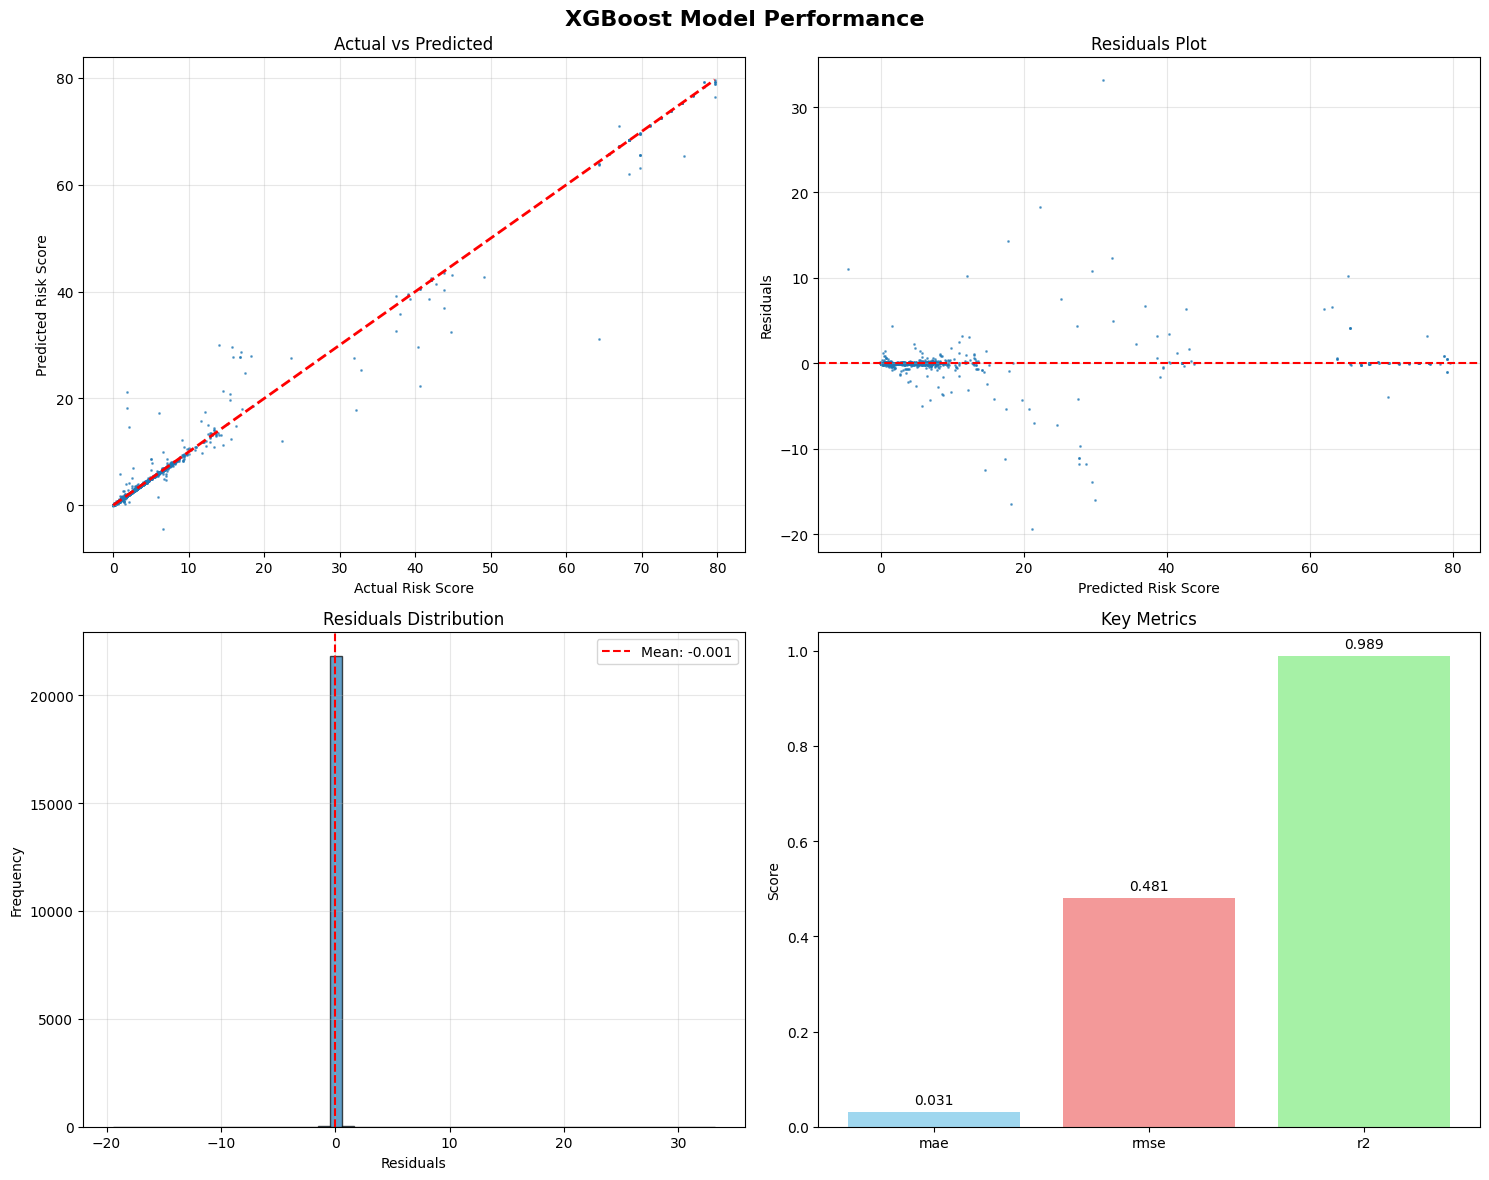

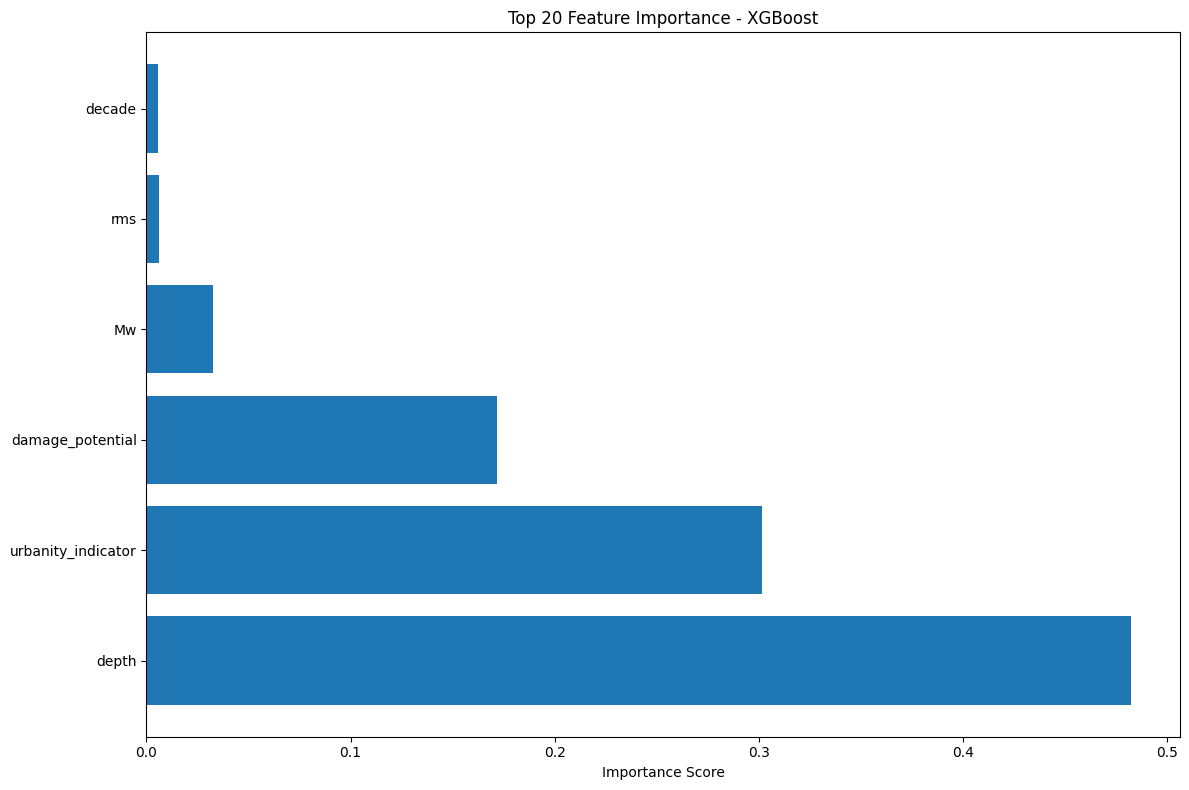

✓ Feature importance plot saved as 'xgboost_importance.png'

Top 20 Most Important Features:
              feature  importance
5              decade      0.0055
1                 rms      0.0062
2                  Mw      0.0326
3    damage_potential      0.1718
4  urbanity_indicator      0.3016
0               depth      0.4823

Saving model to models/xgboost.pkl...
✓ Model and metrics saved successfully!

Model artifacts:
  - Model: models/xgboost.pkl
  - Metrics: models/xgboost_metrics.csv
  - Plots: xgboost_performance.png
  - Plots: xgboost_importance.png

🎉 COMPLETE PIPELINE SUCCESS!


In [8]:
## 8. Run the Full Pipeline
# MAIN EXECUTION - Run the complete pipeline
print("🚀 Starting XGBoost Earthquake Risk Prediction Pipeline")
print("=" * 70)

# 1. Load data
X, y = load_and_prepare_data()

# 2. Train-test split
print("\nSplitting data (80/20)...")
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")

# 3. Train model
model = train_xgboost_model(X_train, y_train)

# 4. Evaluate
metrics = evaluate_model(model, X_val, y_val)

# 5. Visualize
plot_model_performance(metrics)
plot_feature_importance(model, X_train)

# 6. Save
save_model_and_metrics(model, metrics, X_train)

print("\n🎉 COMPLETE PIPELINE SUCCESS!")
print("=" * 70)

In [9]:
## 9. Inference Test
def load_and_predict(model_path: str, new_data: pd.DataFrame):
    """Load saved model and make predictions."""
    model = joblib.load(model_path)
    predictions = model.predict(new_data)
    return predictions

# Test inference
print("🧪 Testing inference...")
test_pred = model.predict(X_val[:5])
print("Sample predictions:", test_pred)
print("✓ Inference working!")

🧪 Testing inference...
Sample predictions: [0.6978942  0.59802914 1.2714179  1.6502973  0.01852782]
✓ Inference working!


🔍 Running SHAP explainability...


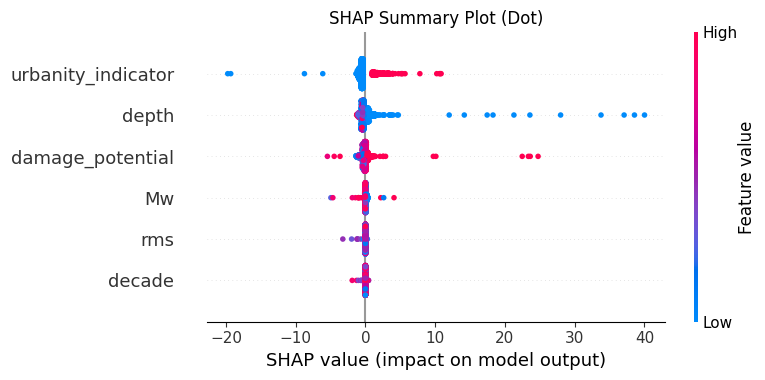

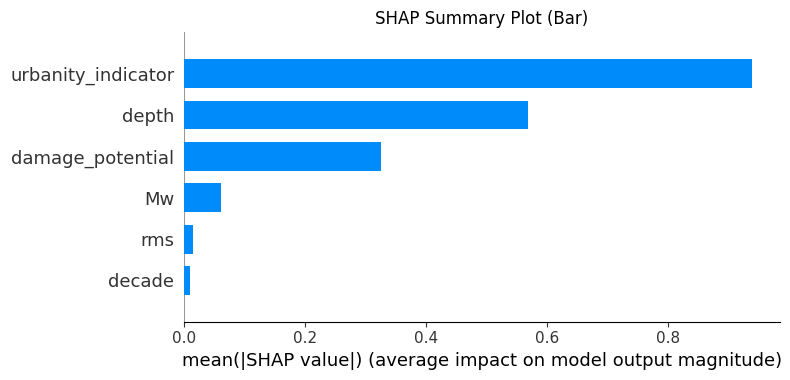


SHAP force plot for sample index: 0


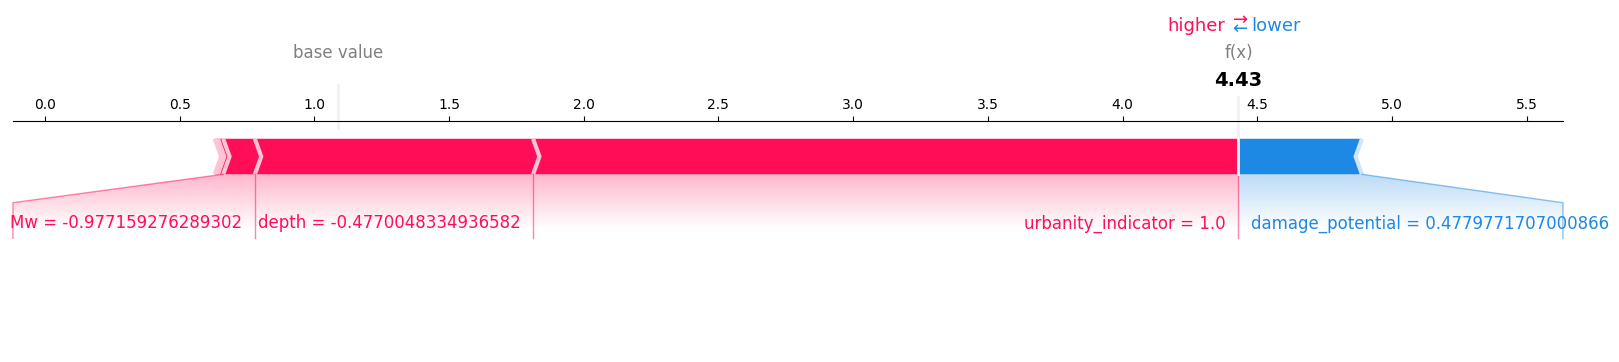

In [10]:
## 10. SHAP Values Analysis
# SHAP explainability for XGBoost
import shap

print("🔍 Running SHAP explainability...")

# 1. Initialize JS visualization (for Notebook)
shap.initjs()

# 2. Create a TreeExplainer for the trained XGBoost model
explainer = shap.TreeExplainer(model)

# 3. Use a sample of training data for speed (optional)
X_sample = X_train.sample(n=2000, random_state=42) if len(X_train) > 2000 else X_train

# 4. Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# 5. Global feature importance (summary plot - dot)
plt.title("SHAP Summary Plot (Dot)")
shap.summary_plot(shap_values, X_sample, show=True)

# 6. Global feature importance (bar plot)
plt.title("SHAP Summary Plot (Bar)")
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=True)

# 7. Example local explanation for a single instance
idx = 0  # change index to inspect other samples
print(f"\nSHAP force plot for sample index: {idx}")
shap.force_plot(
    explainer.expected_value,
    shap_values[idx, :],
    X_sample.iloc[idx, :],
    matplotlib=True
)
